In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds
from src.visualizations.umap_visualizer import UMAPLatent

In [18]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [19]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, dropout=self.dropout)
        # self.linear = nn.Linear(self.hidden_size, self.hidden_size)


    def forward(self, x):
        """
        x: (seq_len, batch_size, input_size=1)
        """
        output, (hidden, cell) = self.lstm(x)
        # output: (seq_len, batch_size, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers. batch_size, hidden_size)
        embeddings = hidden[-1, :, :]
        # embeddings = output[-1, :, :]
        return hidden, cell, embeddings
    
class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.output_size, self.hidden_size, self.num_layers, dropout=self.dropout)
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, x, hidden, cell):
        """
        x: (batch_size)
        hidden: (num_layers, batch_size, hidden_size)
        cell: (num_layers, batch_size, hidden_size)
        """
        x = x.unsqueeze(0)
        # x = (1, batch_size, 1)
        output, (hidden, cell) = self.lstm(x, (hidden, cell))
        # output: (1, batch_size, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        prediction = self.fc(output)
        # prediction: (batch_size, output_size=1)
        return prediction, hidden, cell

In [20]:
class Autoencoder(nn.Module):
    def __init__(self, seq_len, input_size, hidden_size, num_layers, dropout, tf_ratio=1.0):
        super().__init__()
        
        self.seq_len = seq_len
        self.tf_ratio = tf_ratio

        self.encoder = Encoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_size, hidden_size, num_layers, dropout)

    def update_tf_ratio(self, new_tf_ratio):
        self.tf_ratio = new_tf_ratio

    def forward(self, x):
        """
        x: (seq_len, batch_size)
        """
        batch_size = x.shape[1]

        # outputs: (seq_len, batch_size, input_size=1)
        outputs = torch.zeros(self.seq_len, batch_size, self.decoder.output_size)

        hidden, cell, embeddings = self.encoder(x)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        # embeddings: (batch_size, hidden_size)

        input = x[0, :]
        # input: (1, batch_size)
        for t in range(1, self.seq_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            # output = (batch_size, output_size=1)
            # hidden: (num_layers, batch_size, hidden_size)
            # cell: (num_layers, batch_size, hidden_size)
            outputs[t] = output

            teacher_force = random.random() < self.tf_ratio
            input = x[t] if teacher_force else output.squeeze(0)

        return embeddings, outputs
    
    def reconstruct(self, x):
        """
        x: (seq_len, batch_size)
        """
        batch_size = x.shape[1]

        # outputs: (seq_len, batch_size, input_size=1)
        outputs = torch.zeros(self.seq_len, batch_size, self.decoder.output_size)

        hidden, cell, embeddings = self.encoder(x)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        # embeddings: (batch_size, hidden_size)

        input = x[0, :]
        # input: (1, batch_size)
        for t in range(1, self.seq_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            # output = (batch_size, output_size=1)
            # hidden: (num_layers, batch_size, hidden_size)
            # cell: (num_layers, batch_size, hidden_size)
            outputs[t] = output

            input = output.squeeze(0)

        return embeddings, outputs

In [21]:
class AutoencoderTrainer(nn.Module):
    def __init__(self, index_to_class, train_ds, test_ds, num_classes, num_variables, seq_len, input_size, hidden_size, num_layers, dropout, tf_ratio=1.0, min_tf_ratio=0.75, tf_decay=0.001, lr1=0.01, lr2=0.01, epochs1=500, epochs2=500, m=1.0, gamma=0.999, check_latent=True):
        super().__init__()
        self.index_to_class = index_to_class
        self.train_ds = train_ds
        self.test_ds = test_ds
        self.num_classes = num_classes
        self.num_variables = num_variables
        self.seq_len = seq_len
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.tf_ratio = tf_ratio
        self.min_tf_ratio = min_tf_ratio
        self.tf_decay = tf_decay
        self.lr1 = lr1
        self.lr2 = lr2
        self.epochs1 = epochs1
        self.epochs2 = epochs2
        self.m = m
        self.gamma = gamma
        self.check_latent = check_latent
        
        
        self.autoencoders = torch.nn.ModuleList([Autoencoder(seq_len, input_size, hidden_size, num_layers, dropout, tf_ratio) for _ in range(num_variables)])
        self.contrastive_ops = [torch.optim.Adam(ae.encoder.parameters(), lr=lr1) for ae in self.autoencoders]
        self.reconstruction_ops = [torch.optim.Adam(ae.decoder.parameters(), lr=lr2) for ae in self.autoencoders]
        self.contrastive_schedulers = [torch.optim.lr_scheduler.ExponentialLR(opt, gamma) for opt in self.contrastive_ops]
        self.reconstruction_schedulers = [torch.optim.lr_scheduler.ExponentialLR(opt, gamma) for opt in self.reconstruction_ops]

        self.contrastive_loss = SiameseContrastiveLoss(m=self.m)
        self.reconstruction_loss = torch.nn.MSELoss()

        self.contrastive_losses = [[] for _ in range(self.num_variables)]
        self.reconstruction_losses = [[] for _ in range(self.num_variables)]

    def train(self):
        # train_ds is output of get_ds
        data_load = torch.utils.data.DataLoader(self.train_ds, len(self.train_ds), True)

        # First we do contrastive loss
        print("Stage 1: Contrastive Learning")
        for epoch in tqdm(range(self.epochs1)):
            for i in range(self.num_variables):
                for data_matrix, labels in data_load:
                    inp = data_matrix[:, :, i].transpose(0, 1).unsqueeze(2).float()

                    embeddings, output = self.autoencoders[i](inp)
                    loss = self.contrastive_loss(embeddings, labels)
                    self.contrastive_losses[i].append(float(loss))

                    self.contrastive_ops[i].zero_grad()
                    loss.backward()
                    self.contrastive_ops[i].step()
                self.contrastive_schedulers[i].step()

        if self.check_latent:
            self.plot_contrastive_losses()
            self.plot_all_latent_spaces()
            
            
        # Next we do reconstruction loss
        print("Stage 2: Reconstruction Loss")
        for epoch in tqdm(range(self.epochs2)):
            new_tf_ratio = max(self.min_tf_ratio, self.tf_ratio - epoch*self.tf_decay)
            for i in range(self.num_variables):
                for data_matrix, labels in data_load:
                    inp = data_matrix[:, :, i].transpose(0, 1).unsqueeze(2).float()

                    embeddings, output = self.autoencoders[i](inp)
                    loss = self.reconstruction_loss(inp, output)
                    self.reconstruction_losses[i].append(float(loss))

                    self.reconstruction_ops[i].zero_grad()
                    loss.backward()
                    self.reconstruction_ops[i].step()
                self.reconstruction_schedulers[i].step()

                self.autoencoders[i].update_tf_ratio(new_tf_ratio)

        self.plot_contrastive_losses()
        self.plot_reconstruction_losses()

    def plot_contrastive_losses(self, variable=None):
        plt.figure()
        plt.title("Contrastive Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.contrastive_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.contrastive_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_reconstruction_losses(self, variable=None):
        plt.figure()
        plt.title("Reconstruction Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.reconstruction_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.reconstruction_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_all_latent_spaces(self, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        data = torch.utils.data.DataLoader(ds, len(ds), False)
        for data_matrix, labels in data:
            for variable in range(self.num_variables):
                plt.figure()
                inp = data_matrix[:, :, variable].unsqueeze(2).transpose(0, 1).float()
                with torch.no_grad():
                    _, _, embeddings = self.autoencoders[variable].encoder(inp)
                    reducer = umap.UMAP()
                    embeddings_2d = reducer.fit_transform(embeddings)

                    string_labels = np.array([self.index_to_class[float(label)] for label in labels])
                    unique_labels = np.unique(string_labels)
                    for label in unique_labels:
                        idx = string_labels == label
                        plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                plt.legend()
                plt.title("Latent Space for Variable " + str(variable + 1))
                plt.show()

                    

    def plot_one_variable_reconstruction_basicmotions(self, variable, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        print("Reconstruction for variable " + str(variable + 1))
        # View a random train point/reconstruction from each class
        data_load = torch.utils.data.DataLoader(ds, len(ds), False)
        for data_matrix, labels in data_load:
            inp = data_matrix[:, :, variable].transpose(0, 1).unsqueeze(2).float()
            with torch.no_grad():
                # _, output = self.autoencoders[variable](inp)
                _, output = self.autoencoders[variable].reconstruct(inp)
                print("Blue = original, Red = reconstructed")
                plt.figure()
                index = random.randint(0, 9)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]

                plt.title("Standing")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(10, 19)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]

                plt.title("Running")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(20, 29)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]

                plt.title("Walking")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(30, 39)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]


        plt.title("Badminton")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.show()

In [22]:
# Load in BasicMotions dataset
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}
index_to_class = {0:"Standing", 1:"Running", 2:"Walking", 3:"Badminton"}

train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [23]:
trainer = AutoencoderTrainer(
    index_to_class=index_to_class,
    train_ds=train_ds,
    test_ds=test_ds,
    num_classes=4,
    num_variables=6,
    seq_len=100,
    input_size=1,
    hidden_size=20,
    num_layers=2,
    dropout=0,
    tf_ratio=1.0,
    min_tf_ratio=0.5,
    tf_decay=0.001,
    lr1=0.01,
    lr2=0.01,
    epochs1=500,
    epochs2=500,
    m=1.0,
    gamma=0.999,
    check_latent=False
)

Stage 1: Contrastive Learning


100%|██████████| 500/500 [04:08<00:00,  2.02it/s]


Stage 2: Reconstruction Loss


100%|██████████| 500/500 [09:22<00:00,  1.13s/it]


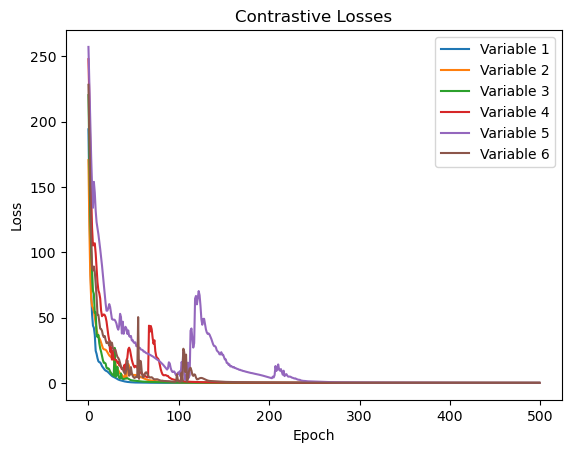

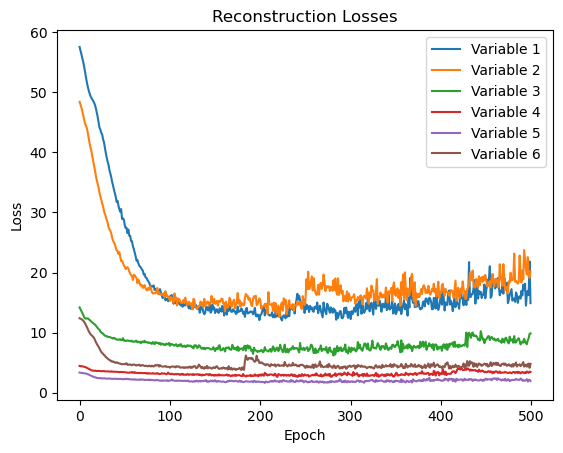

In [24]:
trainer.train()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


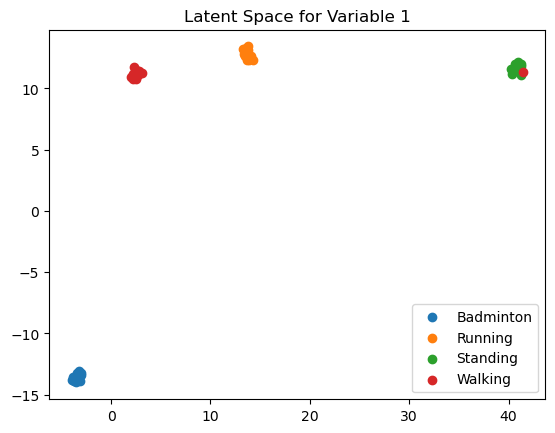

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


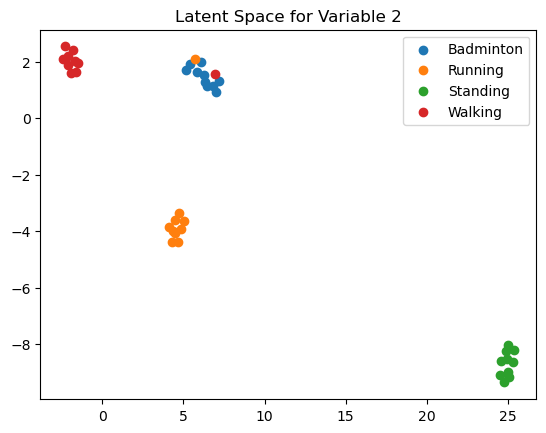

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


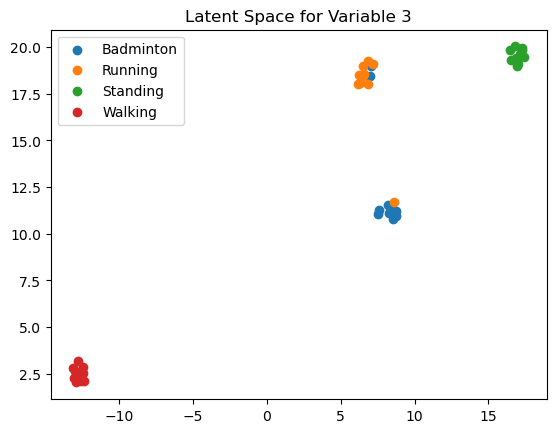

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


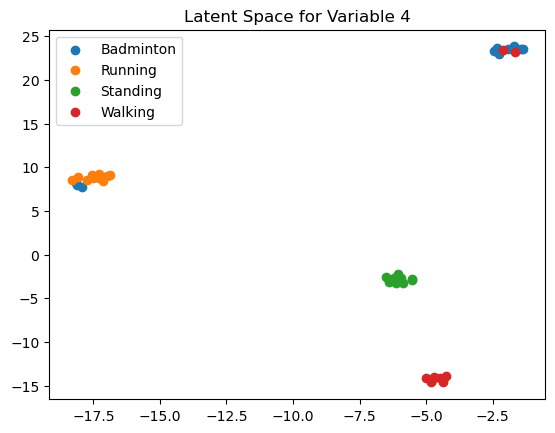

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


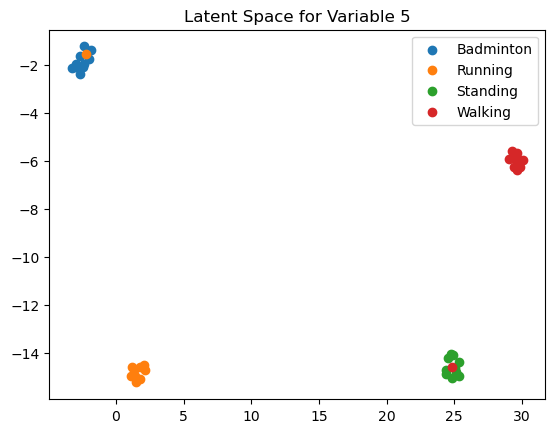

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


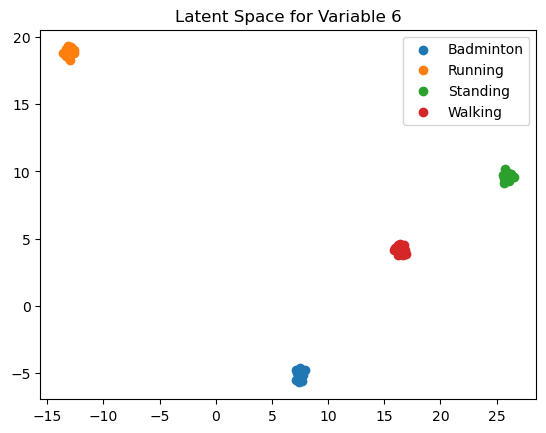

In [25]:
trainer.plot_all_latent_spaces()

Reconstruction for variable 1
Blue = original, Red = reconstructed


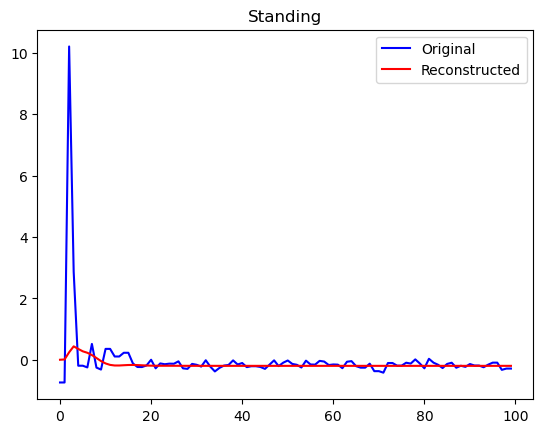

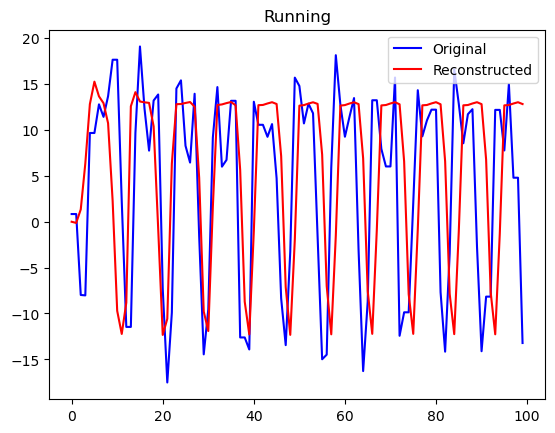

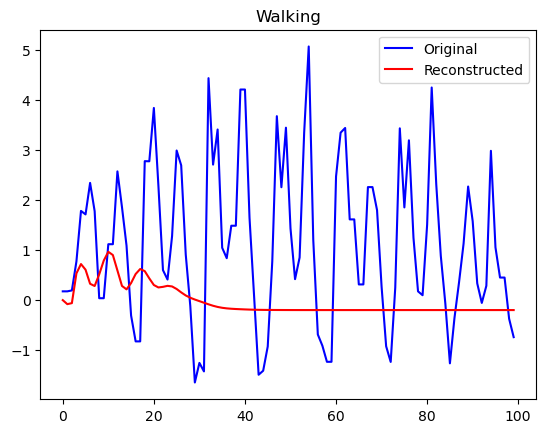

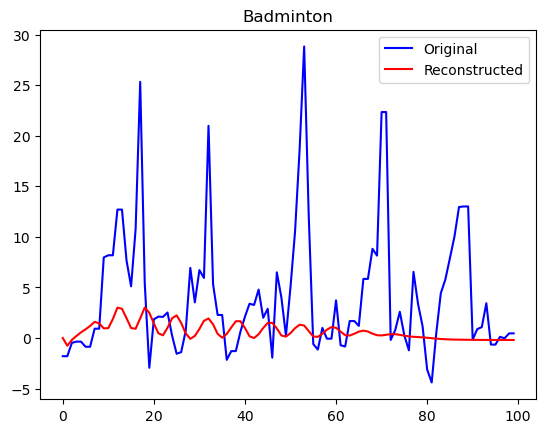

In [26]:
trainer.plot_one_variable_reconstruction_basicmotions(variable=0)

Reconstruction for variable 2
Blue = original, Red = reconstructed


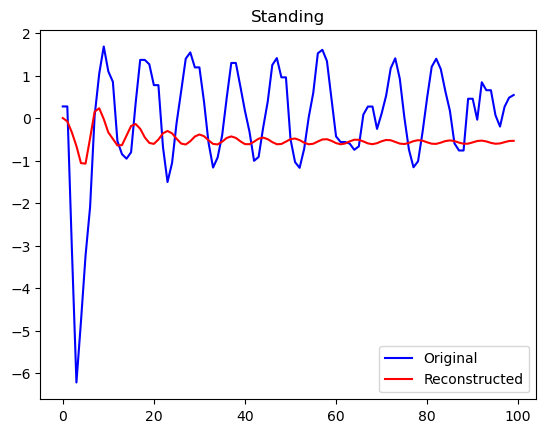

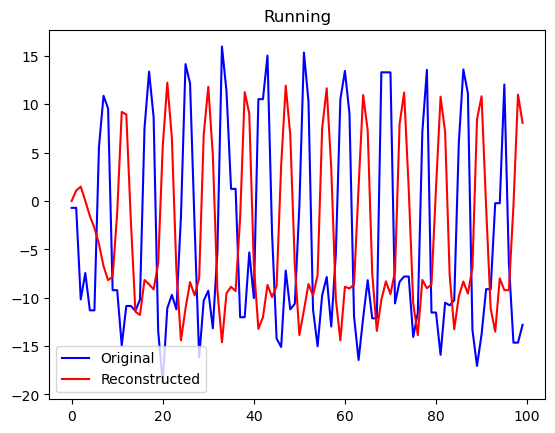

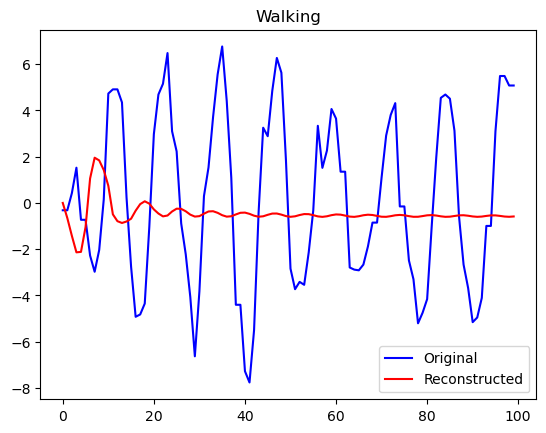

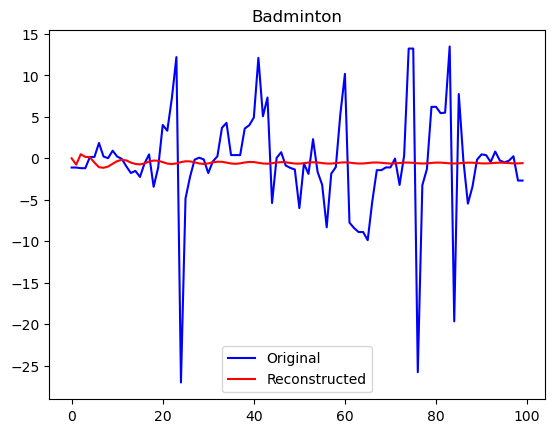

In [27]:
trainer.plot_one_variable_reconstruction_basicmotions(variable=1)

Reconstruction for variable 3
Blue = original, Red = reconstructed


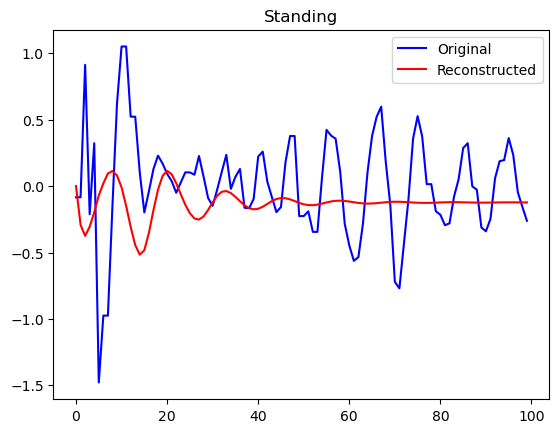

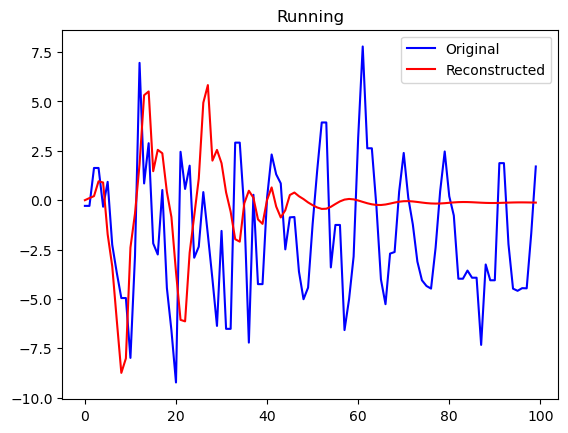

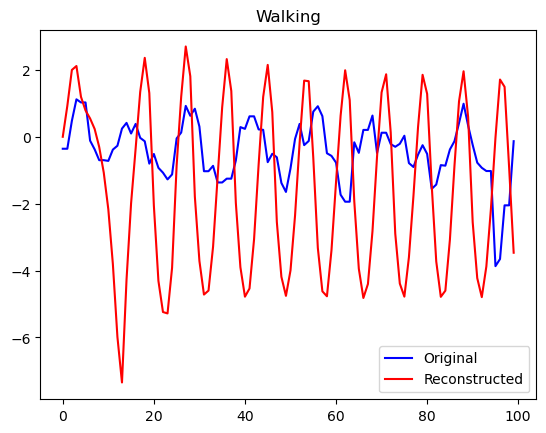

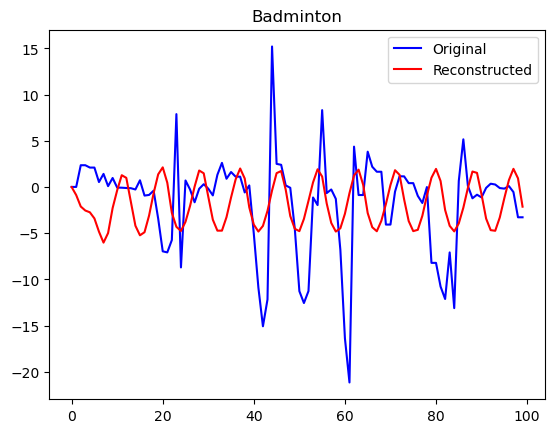

In [28]:
trainer.plot_one_variable_reconstruction_basicmotions(variable=2)

Reconstruction for variable 4
Blue = original, Red = reconstructed


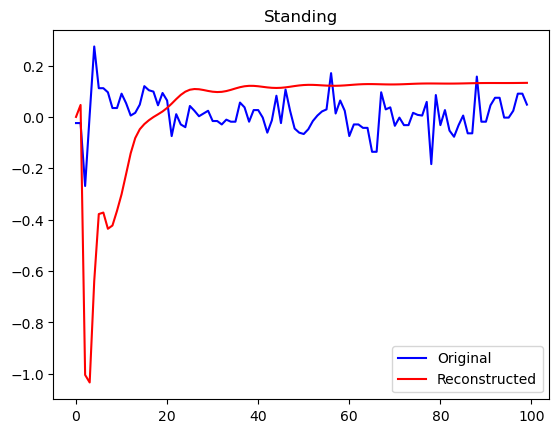

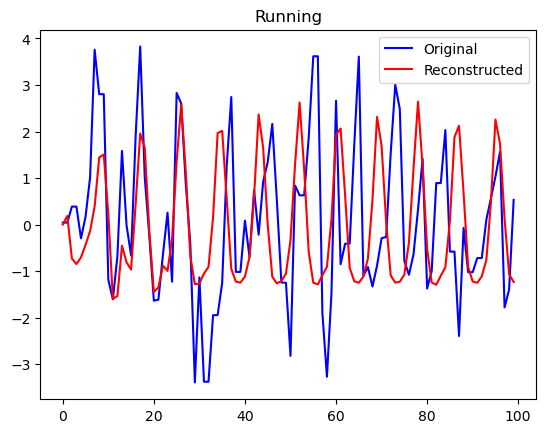

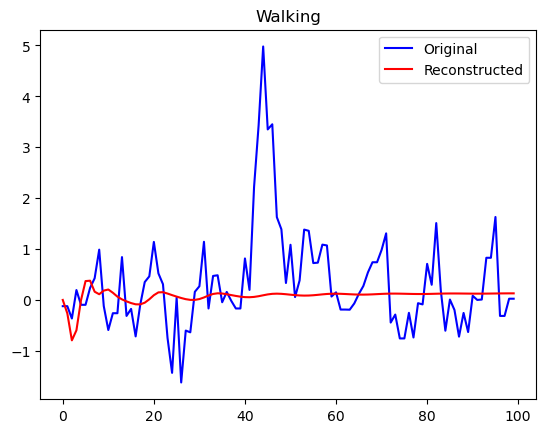

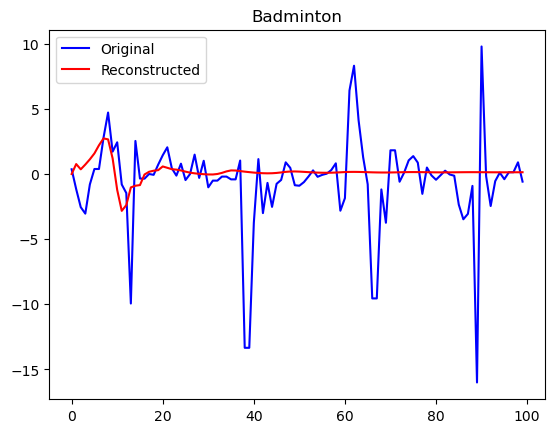

In [29]:
trainer.plot_one_variable_reconstruction_basicmotions(variable=3)

Reconstruction for variable 5
Blue = original, Red = reconstructed


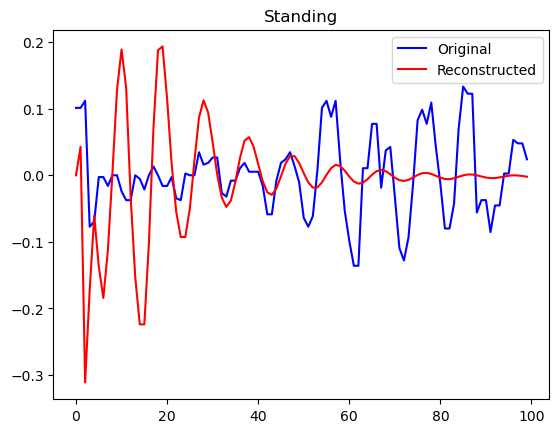

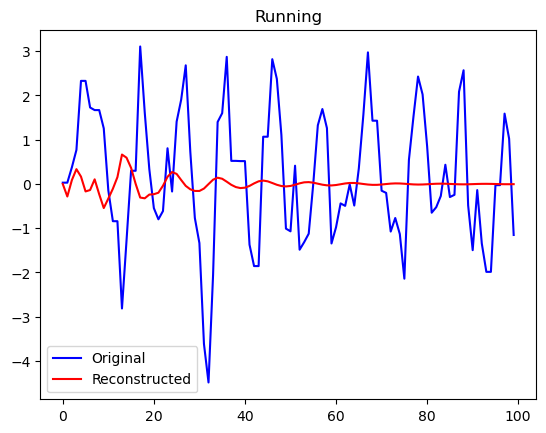

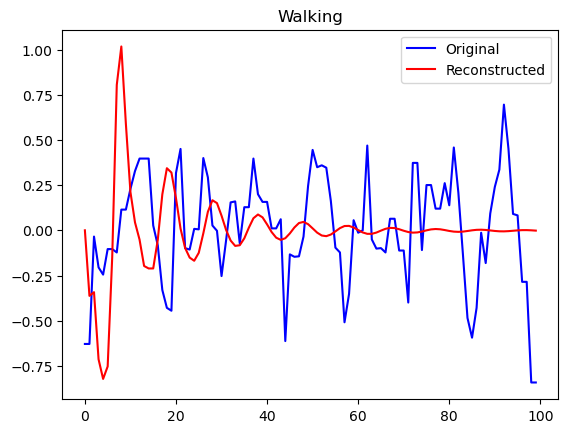

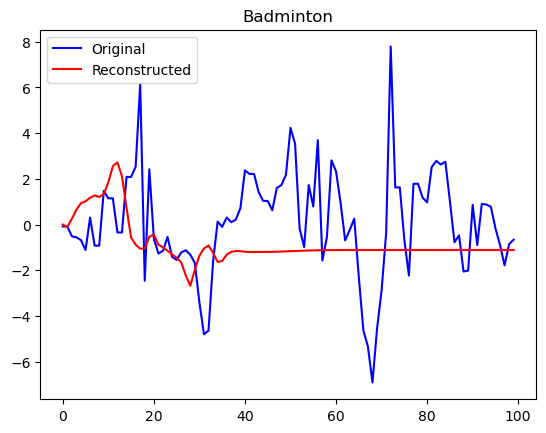

In [30]:
trainer.plot_one_variable_reconstruction_basicmotions(variable=4)

Reconstruction for variable 6
Blue = original, Red = reconstructed


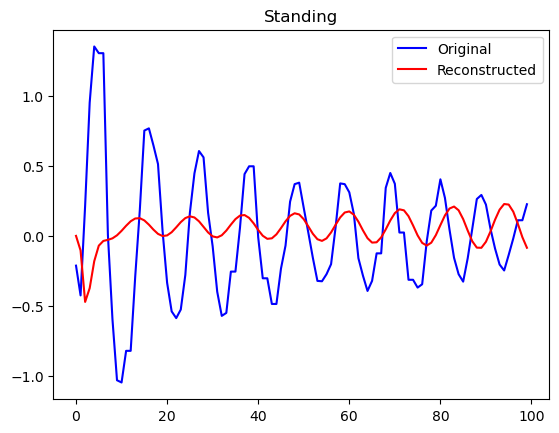

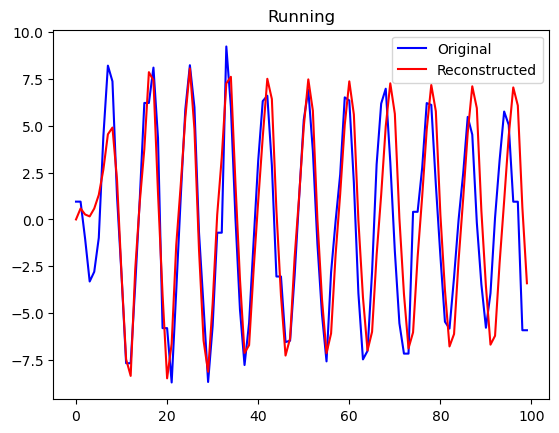

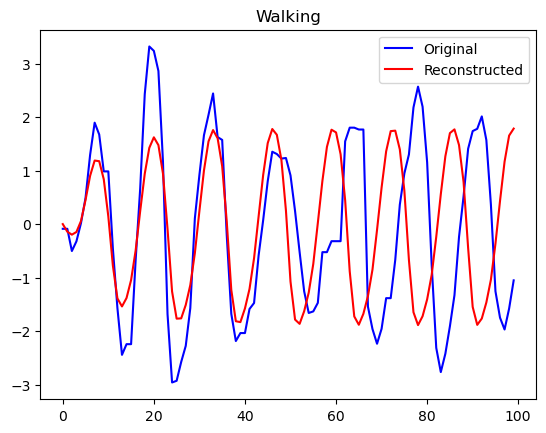

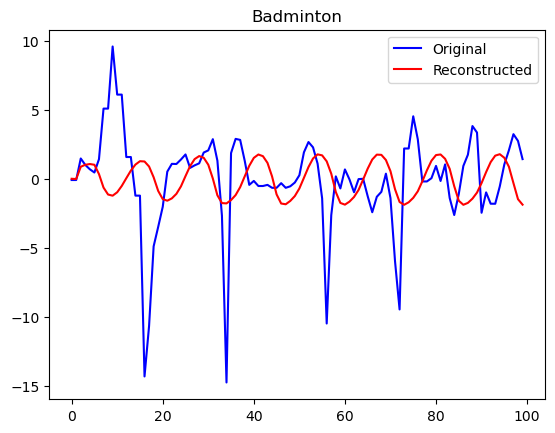

In [31]:
trainer.plot_one_variable_reconstruction_basicmotions(variable=5)

In [32]:
save = False
if save:
    torch.save(trainer.state_dict(), "/Users/bhaveshkalisetti/Desktop/mmbs/models/basicmotions/new/autoencoder.dat")